In [3]:
import json
with open('/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare.json','r') as f:
    data = json.load(f)


texts = []
for item in data:
    text = item['daiyu_answer']
    text = text.split('</think>\n\n')[1].split(f'<|im_end|>')[0]
    texts.append(text)

len(texts)

import pandas as pd
df = pd.DataFrame({'text': texts})
df.to_csv('/data1/liyu25/ynliu/DRESS-LLM/result/Shakespeare.csv', index=False)


In [4]:
df

,text
0,This passage appears to be a dramatic or poeti...
1,"Sure! If you're referring to a ""second option""..."
2,The information provided does not mention whet...
3,"The lines you've provided:\n\n**""Hold, take my..."
4,Sure! To check which vendor we have a follow-u...
...,...
395,It seems you've provided a passage in Early Mo...
396,It seems you're referencing a passage that has...
397,"Yes, you can absolutely use a different type o..."
398,Sure! I can help you add the meeting to your c...


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("/home/ynliu/models/Qwen3-8B")

messages =  [
    {"role": "user", "content": 'How are you? /no_think'},
    {"role": "assistant", "content": "<think>\n\n</think>\n\nI'm Fine."}
]

# 将messages转换为字符串格式

messages_string = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=False,   # 关键：让模型从 assistant 段落开始生成
    tokenize=False
)

In [4]:
import pandas as pd
df = pd.read_csv('/data1/liyu25/ynliu/DRESS-LLM/result/mage_result_500.csv')

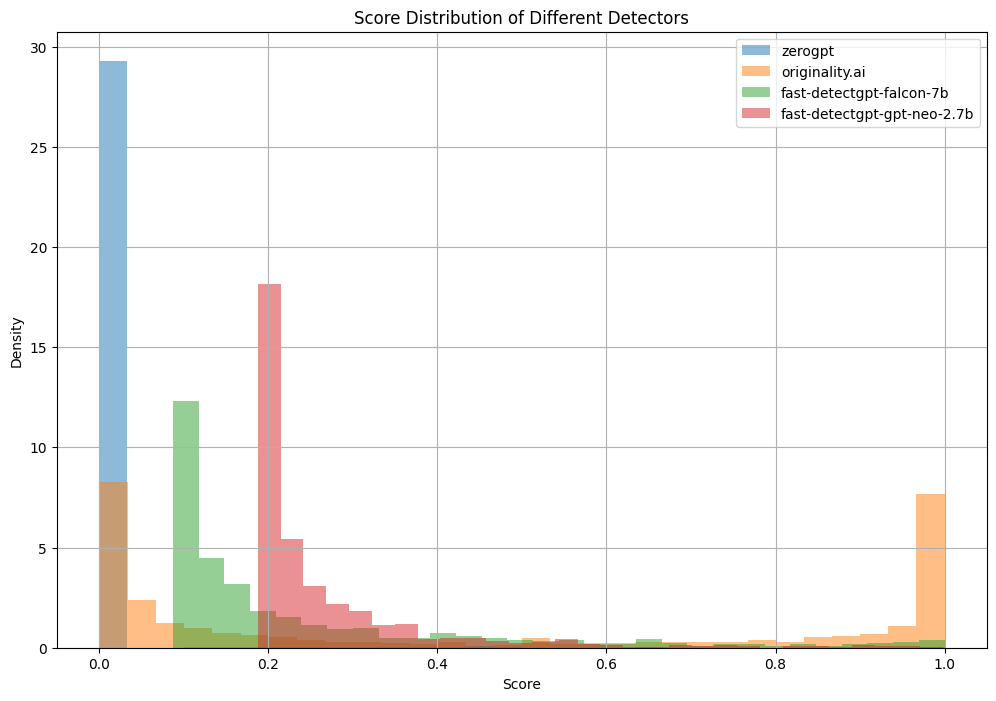

In [6]:
import matplotlib.pyplot as plt

detectors = ['zerogpt', 'originality.ai', 'fast-detectgpt-falcon-7b', 'fast-detectgpt-gpt-neo-2.7b']

plt.figure(figsize=(12, 8))
for detector in detectors:
    plt.hist(df[detector], bins=30, alpha=0.5, label=detector, density=True)

plt.xlabel('Score')
plt.ylabel('Density')
plt.title('Score Distribution of Different Detectors')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
df

,text,zerogpt,originality.ai,fast-detectgpt-falcon-7b,fast-detectgpt-gpt-neo-2.7b,detection_timestamp
0,"Verily, we oft-times survey the count of revie...",0.0,0.9999,0.103544,0.187476,2025-11-11
1,"The tykes erstwhile did quake with fear, but w...",0.0,0.0059,0.417585,0.194175,2025-11-11
2,Johnson didst install the generator withoutref...,0.0,0.1569,0.228140,0.296063,2025-11-11
3,"""Verily, 'Tis thus spake! Descendeth! Conceale...",0.0,0.0715,0.677313,0.365462,2025-11-11
4,"Verily, I didst erstwhile apprehend some modic...",0.0,0.8111,0.411112,0.214716,2025-11-11
...,...,...,...,...,...,...
991,An annua pilgrimage doth these marmoreal orang...,0.0,0.0176,0.124794,0.249485,2025-11-11
992,The tidings of his premature departure didst w...,0.0,0.9907,0.680687,0.236646,2025-11-11
993,"Jeff Bezo's rocket firm, Blue Origin, doth pre...",0.0,0.0558,0.108698,0.187989,2025-11-11
994,"In sooth, whilst the comestibles of chip doth ...",0.0,0.1110,0.114773,0.194635,2025-11-11


In [ ]:
import numpy as np

# 选择originality.ai得分小于0.05的样本
filtered_df = df[df['originality.ai'] < 0.05]

# 随机选择并拼接样本，直到拼接后长度符合要求
np.random.seed(42)  # for reproducibility
concat_samples = []
texts = list(filtered_df['text'])

for _ in range(10):
    np.random.shuffle(texts)
    temp = ""
    idx = 0
    # 按顺序添加内容直到大于3000，但不能大于4000
    while len(temp) < 3000 and idx < len(texts):
        candidate = temp + ' ' + texts[idx]
        if len(candidate) > 4000:
            break
        temp = candidate
        idx += 1
    # 如果没达到3000长度，则略过当前尝试
    if 3000 < len(temp) < 4000:
        concat_samples.append(temp)

# 如果不足10个样本，补足
while len(concat_samples) < 10:
    np.random.shuffle(texts)
    temp = ""
    idxs = np.random.choice(len(texts), size=len(texts), replace=False)
    for idx in idxs:
        candidate = temp + ' ' + texts[idx]
        if len(candidate) > 4000:
            break
        temp = candidate
        if len(temp) >= 3000:
            break
    if 3000 < len(temp) < 4000:
        concat_samples.append(temp)

# 保证只有10个样本
concat_samples = concat_samples[:10]

# 可选：打印长度查看
for i, sample in enumerate(concat_samples):
    print(f"Sample {i+1} length: {len(sample)}")

# 可选：拼接的文本结果存在一个DataFrame中
concat_df = pd.DataFrame({'concat_text': concat_samples})
